In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import mplfinance as mpf
import xgboost as xgb
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

In [2]:
data = pd.read_csv('StockData.csv')

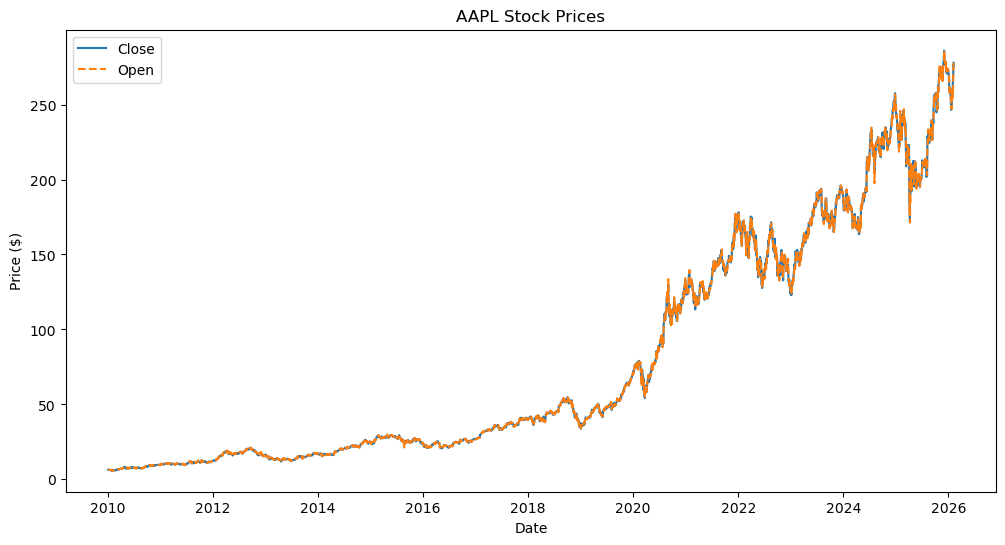

In [4]:
plt.figure(figsize=(12,6))
plt.plot(data.index, data['Close'], label='Close')
plt.plot(data.index, data['Open'], label='Open', linestyle='--')
plt.title("AAPL Stock Prices")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend()
plt.show()

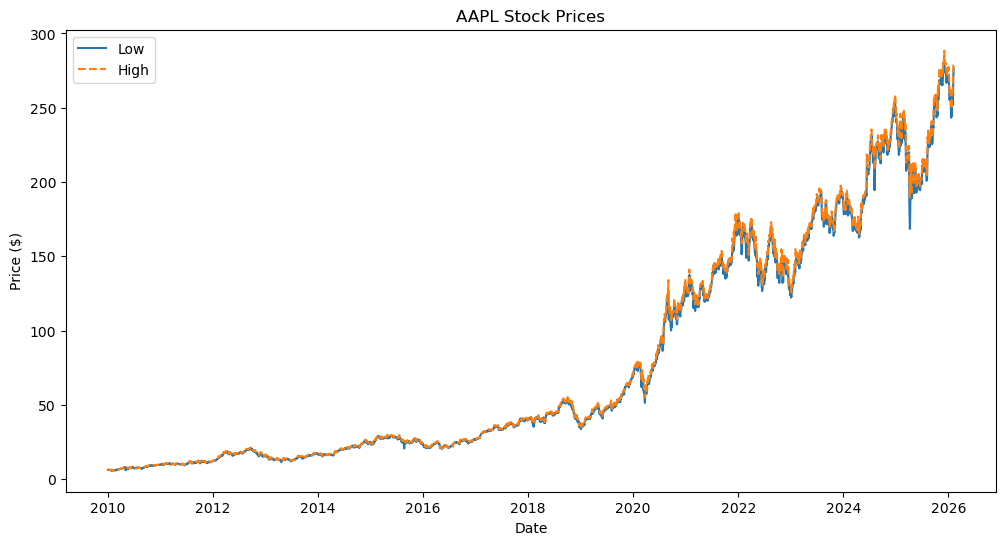

In [5]:
plt.figure(figsize=(12,6))
plt.plot(data.index, data['Low'], label='Low')
plt.plot(data.index, data['High'], label='High', linestyle='--')
plt.title("AAPL Stock Prices")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend()
plt.show()

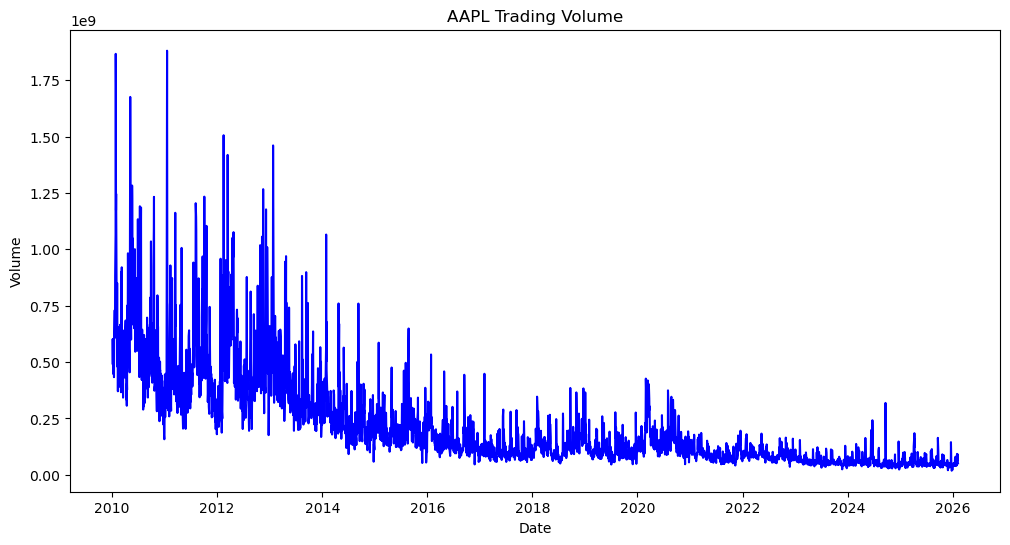

In [6]:
plt.figure(figsize=(12,6))
plt.plot(data.index, data['Volume'], color='blue')
plt.title("AAPL Trading Volume")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.show()

In [3]:
df = data

feature_columns = df.columns.to_list()
feature_columns.remove("date")
feature_columns.remove("ticker")

In [4]:
X = df[feature_columns]
y = df["TARGET"]

split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [5]:
import numpy as np
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = X_train.copy()
X_test = X_test.copy()

num_cols = X_train.select_dtypes(include=np.number).columns

X_train.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test.replace([np.inf, -np.inf], np.nan, inplace=True)

X_train[num_cols] = X_train[num_cols].fillna(X_train[num_cols].median())
X_test[num_cols] = X_test[num_cols].fillna(X_train[num_cols].median())

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

X_train = X_train.drop(columns=["date", "ticker"])
X_test = X_test.drop(columns=["date", "ticker"])

KeyError: "['date', 'ticker'] not found in axis"

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
model = xgb.XGBClassifier(
    objective="binary:logistic",
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
model.fit(X_train, y_train)

In [17]:
y_pred = model.predict(X_test)

In [18]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 1.0000


In [19]:
param_dist = {
    'n_estimators': [200, 400, 600, 800, 1000],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

In [20]:
random_search = RandomizedSearchCV(
    model,
    param_distributions=param_dist,
    n_iter=100,
    cv=5,
    n_jobs=-1,
    verbose=2,
    random_state=42
)

In [21]:
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=0.8, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constraint...
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=200, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=100, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [3, 5, 7, 9],
                                        'n_estimators': [200, 400, 600, 800,
                                                         1000],
                                        'subsample': [0.6, 0.8]},
                   random_state=42, verbose=2)

In [22]:
print(f'Best parameter: {random_search.best_params_}')
print(f"Best CV score: {random_search.best_score_}")
tuned_model = random_search.best_estimator_

Best parameter: {'subsample': 0.8, 'n_estimators': 400, 'max_depth': 9, 'learning_rate': 0.05, 'colsample_bytree': 0.6}
Best CV score: 1.0


In [24]:
y_pred = tuned_model.predict(X_test) 
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 1.0000


In [28]:
from sklearn.metrics import classification_report, confusion_matrix

preds = tuned_model.predict(X_test)

print(confusion_matrix(y_test, preds))
print(classification_report(y_test, preds))

[[1346    0]
 [   0  211]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1346
           1       1.00      1.00      1.00       211

    accuracy                           1.00      1557
   macro avg       1.00      1.00      1.00      1557
weighted avg       1.00      1.00      1.00      1557



In [30]:
train_acc = tuned_model.score(X_train, y_train)
test_acc = tuned_model.score(X_test, y_test)

print(train_acc, test_acc)

1.0 1.0


In [44]:
importance = pd.Series(tuned_model.feature_importances_, index=feature_columns)
print(importance.sort_values(ascending=False))

TARGET                      0.362568
INCREMENTO                  0.194725
diff                        0.047288
bollingerBU10-10adjclose    0.028847
close                       0.021820
                              ...   
stochastic-k-5              0.000000
hammer1y3lowhighvolume      0.000000
hammer1y3lowlowhigh         0.000000
hammer1y3lowlowlow          0.000000
cci25                       0.000000
Length: 1283, dtype: float32


In [46]:
import joblib
joblib.dump(tuned_model, "stock_classifier_model.pk1")

['stock_classifier_model.pk1']

In [6]:
df['ticker'].unique()

array(['ASLE', 'ASLN', 'ASMB', 'ASML', 'ASND', 'ASO', 'ASPA', 'ASPAU',
       'ASPS', 'ASRT', 'ASRV', 'ASTC', 'ASTE', 'ASTL', 'ASTR', 'ASTS',
       'ASUR', 'ASYS', 'ATAI', 'ATCOL', 'ATEC', 'ATER', 'ATEX', 'ATHA',
       'ATHE', 'ATHX', 'ATIF', 'ATLC', 'ATLCL', 'ATLCP', 'ATLO'],
      dtype=object)